# Réseaux de neuronnes 1 : perceptron avec fonction sigmoïde

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

(100, 2)
(100, 1)


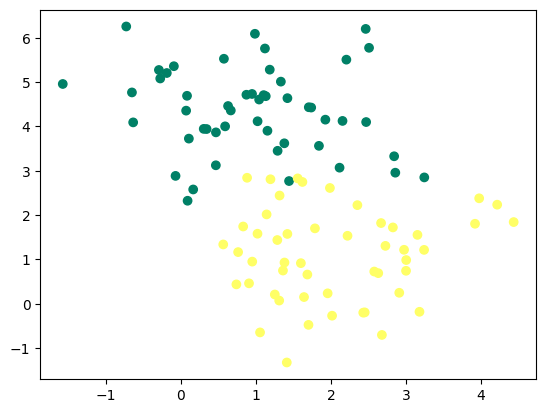

In [40]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print(X.shape)
print(y.shape)

plt.scatter(X[:,0], X[:,1], c=y , cmap='summer')
plt.show()

In [41]:
#Initialization 

def Initialization(X):
    W = np.random.randn(X.shape[1],1)
    b = np.random.randn(1)
    return (W, b)

In [42]:
# Modèle

def Model(X, W, b):
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-Z))
    return A

In [43]:
# Cost function 

def LogLoss(y, A):
    m = len(y)
    L = - (1/m) * np.sum(y * np.log(A) + (1 -y) * (np.log(1 - A)))
    return L 

# Gradient

def Gradient(X, y, A):
    m = len(y)
    dw = np.dot(X.T, A - y) / m
    db = np.sum(A - y)/ m
    return (dw, db)

# Gradient descent

def GradientDescent(dw, db, W, b, learning_rate):
    W = W -learning_rate * dw
    b = b -learning_rate * db
    return (W, b)


In [44]:
def predict(X, W, b):
    A = Model(X, W, b)
    print(A) #proba d'être 1
    return A>=0.5

In [45]:
from sklearn.metrics import accuracy_score

In [46]:
def artificial_neuron(X, y, learning_rate = 0.1, n_iteration = 100):
    # init W & b
    W, b = Initialization(X)
    Loss = []

    for i in range(n_iteration):
        A = Model(X, W, b)
        Loss.append(LogLoss(y, A))
        dW, db = Gradient(X, y, A)
        W, b = GradientDescent(dW, db, W, b, learning_rate)
    
    y_pred = predict(X, W, b)
    print(accuracy_score(y, y_pred))


    plt.plot(Loss)
    plt.show()

    return (W, b)

[[9.72389639e-01]
 [7.25559980e-01]
 [5.43508387e-03]
 [1.22336285e-01]
 [9.64280872e-01]
 [3.47247225e-01]
 [7.35469552e-02]
 [9.56929803e-01]
 [4.79191653e-02]
 [8.42555186e-01]
 [3.24279686e-02]
 [8.58095901e-01]
 [2.98029484e-02]
 [1.74872889e-02]
 [7.09145690e-01]
 [9.85844410e-01]
 [9.90160301e-01]
 [3.53082408e-02]
 [6.84379828e-01]
 [6.20788481e-01]
 [4.95105607e-02]
 [3.74103751e-02]
 [3.84447860e-01]
 [5.39306911e-03]
 [9.48239585e-01]
 [3.46404258e-02]
 [8.68930767e-01]
 [1.04291893e-02]
 [7.38140930e-02]
 [7.52814933e-01]
 [9.74472703e-01]
 [4.76222831e-02]
 [6.31599777e-01]
 [9.74952565e-01]
 [4.07162169e-01]
 [2.59724356e-01]
 [7.55139581e-01]
 [5.60643089e-01]
 [4.88861347e-01]
 [4.11450362e-01]
 [6.04792062e-02]
 [9.70999866e-02]
 [9.29247332e-04]
 [1.72798716e-01]
 [1.91130742e-01]
 [8.36379397e-01]
 [9.59415437e-01]
 [9.50498365e-01]
 [4.53141782e-03]
 [1.06178941e-02]
 [9.29590359e-01]
 [5.18948217e-01]
 [6.20927659e-02]
 [4.66332391e-02]
 [8.40871222e-01]
 [4.672766

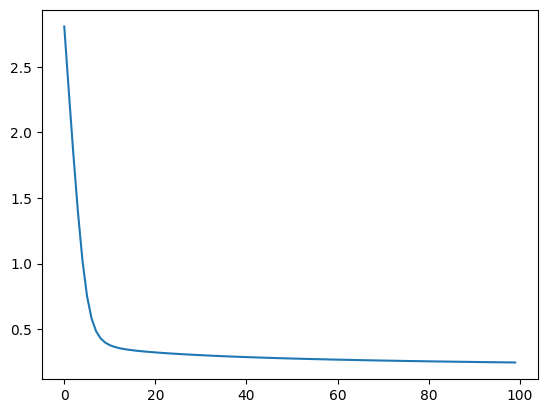

In [47]:
W, b = artificial_neuron(X, y)

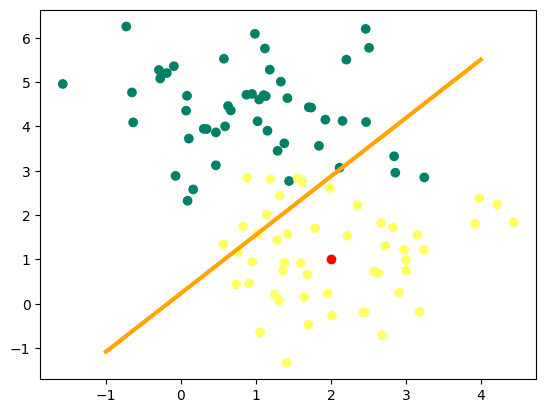

[0.86664709]


array([ True])

In [48]:
# new prediction 

# To have the separating line:
x0 = np.linspace(-1, 4, 100)
x1 = (- W[0]*x0 - b) / W[1]

new_plant = np.array([2, 1])
plt.scatter(X[:,0], X[:,1], c=y , cmap='summer')
plt.scatter(new_plant[0], new_plant[1], c = 'r')
plt.plot(x0, x1, c='orange', lw = 3)

plt.show()

predict(new_plant, W, b)